In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8')

print("All libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


All libraries loaded successfully!
Pandas version: 2.3.3
NumPy version: 2.4.4


In [2]:
# Load the transaction data
print("Loading dataset... this may take 30-60 seconds")

df_transaction = pd.read_csv('../data/raw/train_transaction.csv')
df_identity = pd.read_csv('../data/raw/train_identity.csv')

print(f"Transaction data shape: {df_transaction.shape}")
print(f"Identity data shape: {df_identity.shape}")
print(f"\nTransaction columns: {df_transaction.shape[1]}")
print(f"Identity columns: {df_identity.shape[1]}")
print(f"\nTotal transactions: {df_transaction.shape[0]:,}")

Loading dataset... this may take 30-60 seconds
Transaction data shape: (590540, 394)
Identity data shape: (144233, 41)

Transaction columns: 394
Identity columns: 41

Total transactions: 590,540


Not Fraud (0): 569,877
Fraud (1):     20,663

Fraud rate: 3.50%
Class imbalance ratio: 28:1


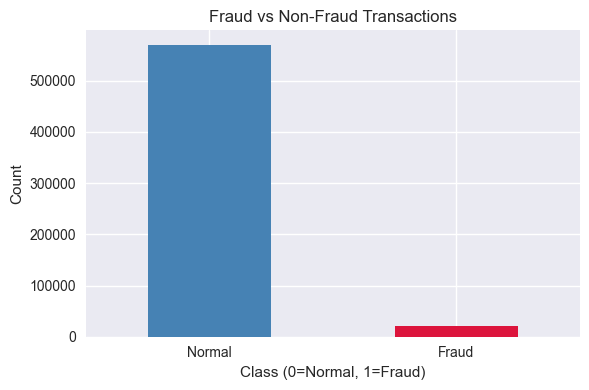

In [3]:
# Check class imbalance
fraud_count = df_transaction['isFraud'].value_counts()
fraud_rate = df_transaction['isFraud'].mean() * 100

print(f"Not Fraud (0): {fraud_count[0]:,}")
print(f"Fraud (1):     {fraud_count[1]:,}")
print(f"\nFraud rate: {fraud_rate:.2f}%")
print(f"Class imbalance ratio: {fraud_count[0]/fraud_count[1]:.0f}:1")

# Visualise
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
fraud_count.plot(kind='bar', ax=ax, color=['steelblue', 'crimson'])
ax.set_title('Fraud vs Non-Fraud Transactions')
ax.set_xlabel('Class (0=Normal, 1=Fraud)')
ax.set_ylabel('Count')
ax.set_xticklabels(['Normal', 'Fraud'], rotation=0)
plt.tight_layout()
plt.show()

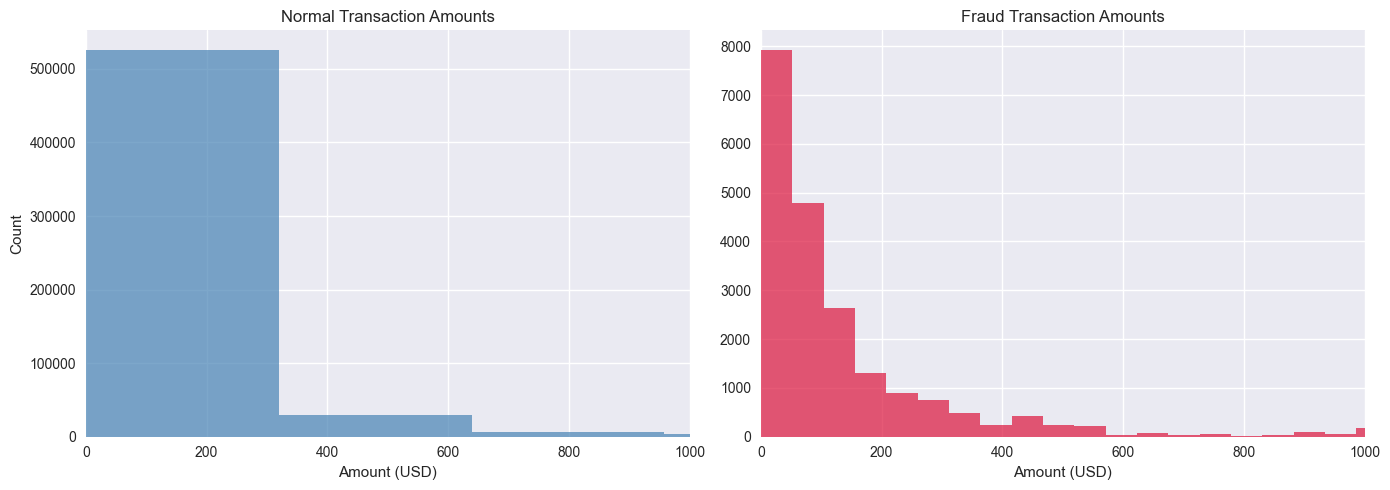

Normal - Mean: $134.51
Fraud  - Mean: $149.24


In [4]:
# Transaction amount analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal transactions
axes[0].hist(df_transaction[df_transaction['isFraud']==0]['TransactionAmt'], 
             bins=100, color='steelblue', alpha=0.7)
axes[0].set_title('Normal Transaction Amounts')
axes[0].set_xlabel('Amount (USD)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1000)

# Fraud transactions
axes[1].hist(df_transaction[df_transaction['isFraud']==1]['TransactionAmt'], 
             bins=100, color='crimson', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount (USD)')
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

print(f"Normal - Mean: ${df_transaction[df_transaction['isFraud']==0]['TransactionAmt'].mean():.2f}")
print(f"Fraud  - Mean: ${df_transaction[df_transaction['isFraud']==1]['TransactionAmt'].mean():.2f}")

In [5]:
# Missing value analysis
missing = df_transaction.isnull().sum()
missing_pct = (missing / len(df_transaction) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

# Show top 20 columns with most missing values
print("Top 20 columns with most missing values:")
print(missing_df[missing_df['missing_count'] > 0].head(20))

print(f"\nTotal columns with missing values: {(missing > 0).sum()}")
print(f"Total columns with >50% missing: {(missing_pct > 50).sum()}")

Top 20 columns with most missing values:
       missing_count  missing_pct
dist2         552913        93.63
D7            551623        93.41
D13           528588        89.51
D14           528353        89.47
D12           525823        89.04
D6            517353        87.61
D9            515614        87.31
D8            515614        87.31
V153          508595        86.12
V140          508595        86.12
V150          508589        86.12
V149          508595        86.12
V155          508595        86.12
V147          508595        86.12
V146          508595        86.12
V145          508589        86.12
V144          508589        86.12
V143          508589        86.12
V142          508595        86.12
V141          508595        86.12

Total columns with missing values: 374
Total columns with >50% missing: 174


In [6]:
# Basic dataset overview
print("=== DATASET SUMMARY ===")
print(f"\nTotal transactions: {len(df_transaction):,}")
print(f"Fraud transactions: {df_transaction['isFraud'].sum():,}")
print(f"Fraud rate: {df_transaction['isFraud'].mean()*100:.2f}%")
print(f"Class imbalance: {(1-df_transaction['isFraud'].mean())/df_transaction['isFraud'].mean():.0f}:1")
print(f"\nTotal features: {df_transaction.shape[1]}")
print(f"Features with missing values: 374")
print(f"Features with >50% missing: 174")
print(f"\nTransaction amount range: ${df_transaction['TransactionAmt'].min():.2f} - ${df_transaction['TransactionAmt'].max():,.2f}")
print(f"Mean fraud amount: $149.24")
print(f"Mean normal amount: $134.51")

print("\n=== KEY FINDINGS FOR EDA ===")
print("1. Severe class imbalance (28:1) - must use AUC-ROC not accuracy")
print("2. 174 features >50% missing - need careful imputation strategy")
print("3. Fraud transactions slightly higher value on average")
print("4. Both distributions heavily right-skewed - consider log transform")


=== DATASET SUMMARY ===

Total transactions: 590,540
Fraud transactions: 20,663
Fraud rate: 3.50%
Class imbalance: 28:1

Total features: 394
Features with missing values: 374
Features with >50% missing: 174

Transaction amount range: $0.25 - $31,937.39
Mean fraud amount: $149.24
Mean normal amount: $134.51

=== KEY FINDINGS FOR EDA ===
1. Severe class imbalance (28:1) - must use AUC-ROC not accuracy
2. 174 features >50% missing - need careful imputation strategy
3. Fraud transactions slightly higher value on average
4. Both distributions heavily right-skewed - consider log transform


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8')

# Reload data
print("Loading data...")
df_transaction = pd.read_csv('../data/raw/train_transaction.csv')
df_identity = pd.read_csv('../data/raw/train_identity.csv')
print(f"Loaded {len(df_transaction):,} transactions")

Loading data...
Loaded 590,540 transactions


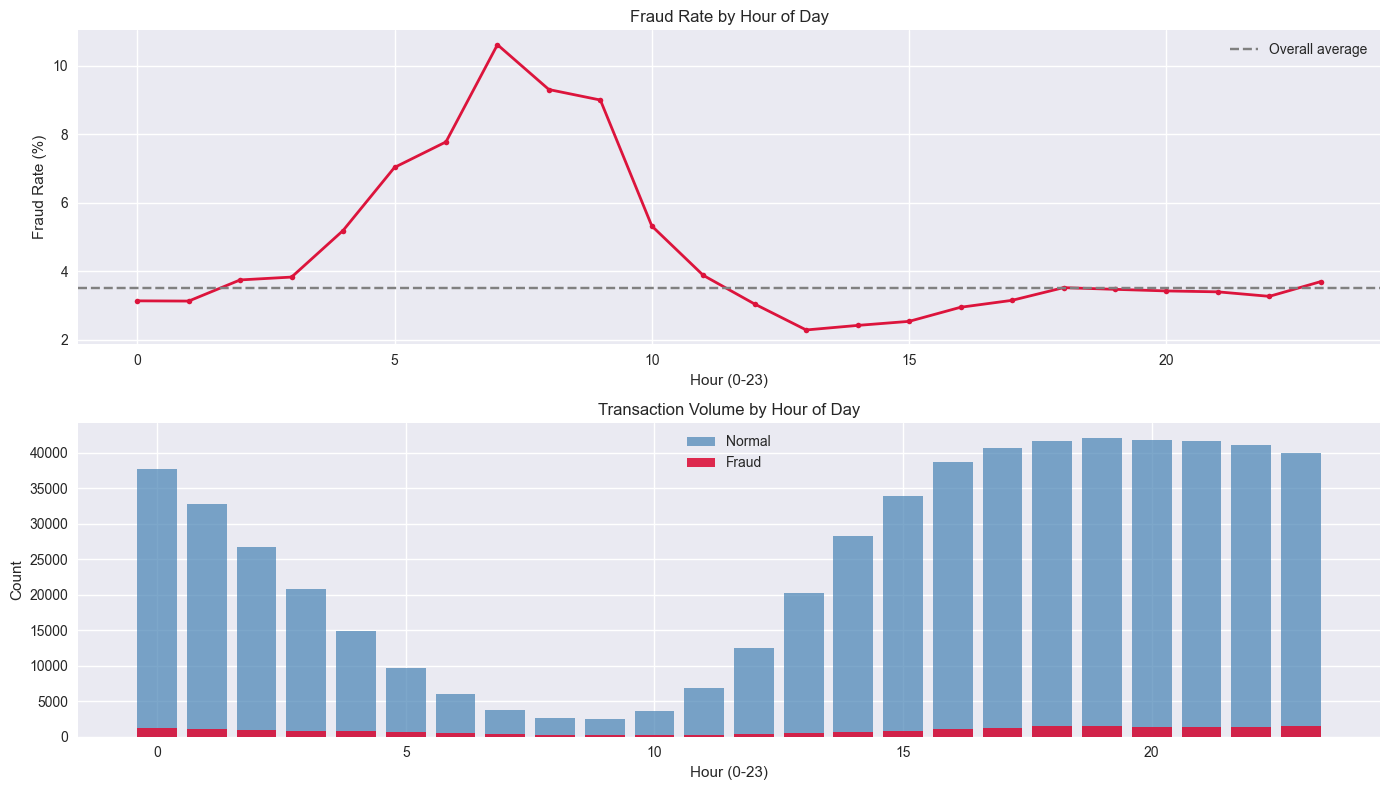

Peak fraud hour: 7:00 (10.61% fraud rate)
Lowest fraud hour: 13:00 (2.29% fraud rate)


In [2]:
# Fraud patterns by time of day
# TransactionDT is seconds from a reference point
df_transaction['hour'] = (df_transaction['TransactionDT'] // 3600) % 24

hourly = df_transaction.groupby('hour')['isFraud'].agg(['sum', 'count', 'mean'])
hourly.columns = ['fraud_count', 'total_count', 'fraud_rate']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Fraud rate by hour
axes[0].plot(hourly.index, hourly['fraud_rate'] * 100, 
             color='crimson', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].axhline(y=df_transaction['isFraud'].mean()*100, 
                color='gray', linestyle='--', label='Overall average')
axes[0].legend()

# Transaction volume by hour
axes[1].bar(hourly.index, hourly['total_count'], 
            color='steelblue', alpha=0.7, label='Normal')
axes[1].bar(hourly.index, hourly['fraud_count'], 
            color='crimson', alpha=0.9, label='Fraud')
axes[1].set_title('Transaction Volume by Hour of Day')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Peak fraud hour: {hourly['fraud_rate'].idxmax()}:00 "
      f"({hourly['fraud_rate'].max()*100:.2f}% fraud rate)")
print(f"Lowest fraud hour: {hourly['fraud_rate'].idxmin()}:00 "
      f"({hourly['fraud_rate'].min()*100:.2f}% fraud rate)")

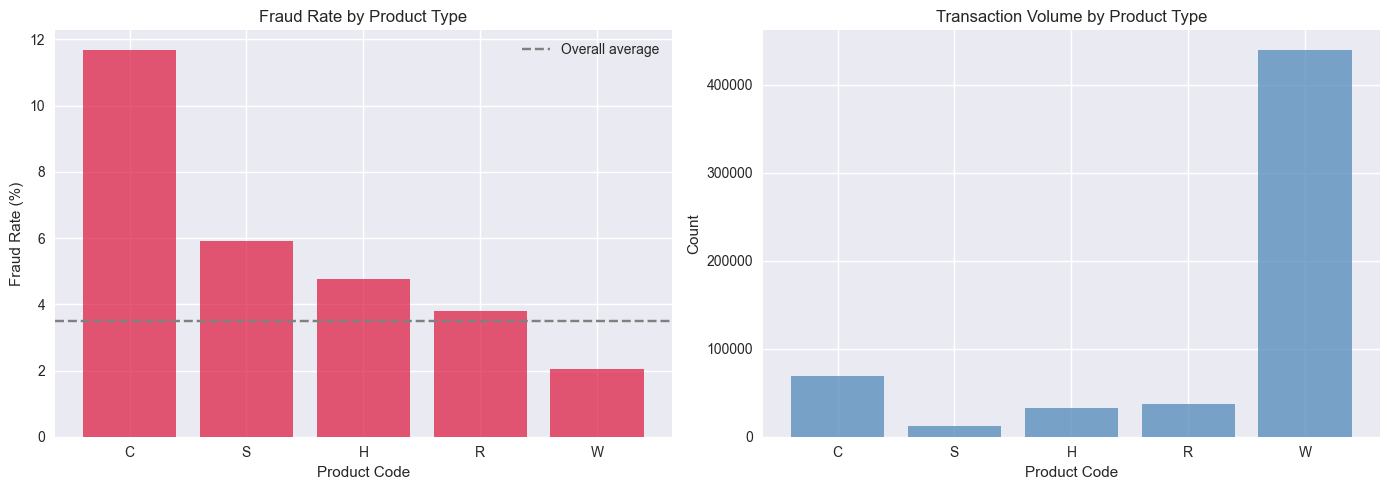

Fraud rate by product:
           fraud_rate   count
ProductCD                    
C            0.116873   68519
S            0.058996   11628
H            0.047662   33024
R            0.037826   37699
W            0.020399  439670


In [3]:
# Fraud by product type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by ProductCD
product_fraud = df_transaction.groupby('ProductCD')['isFraud'].agg(['mean', 'count'])
product_fraud.columns = ['fraud_rate', 'count']
product_fraud = product_fraud.sort_values('fraud_rate', ascending=False)

axes[0].bar(product_fraud.index, product_fraud['fraud_rate'] * 100, 
            color='crimson', alpha=0.7)
axes[0].set_title('Fraud Rate by Product Type')
axes[0].set_xlabel('Product Code')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].axhline(y=df_transaction['isFraud'].mean()*100, 
                color='gray', linestyle='--', label='Overall average')
axes[0].legend()

# Transaction count by ProductCD
axes[1].bar(product_fraud.index, product_fraud['count'], 
            color='steelblue', alpha=0.7)
axes[1].set_title('Transaction Volume by Product Type')
axes[1].set_xlabel('Product Code')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Fraud rate by product:")
print(product_fraud[['fraud_rate', 'count']].to_string())

Top 15 features most correlated with fraud:
V257    0.3831
V246    0.3669
V244    0.3641
V242    0.3606
V201    0.3280
V200    0.3188
V189    0.3082
V188    0.3036
V258    0.2972
V45     0.2818
V158    0.2781
V156    0.2760
V149    0.2733
V228    0.2689
V44     0.2604
Name: isFraud, dtype: float64


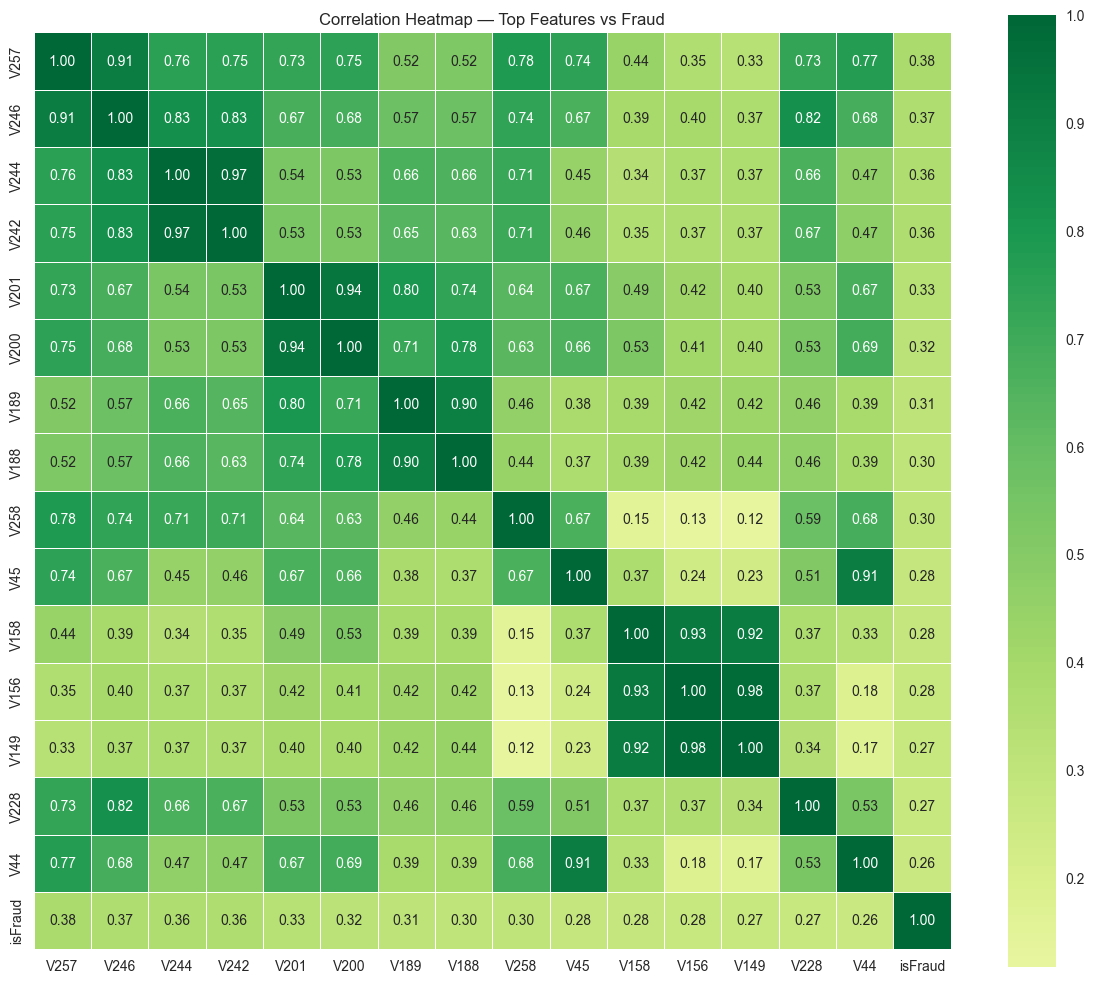

In [4]:
# Correlation heatmap of numeric features with isFraud
numeric_cols = df_transaction.select_dtypes(include=[np.number]).columns.tolist()

# Get top 15 most correlated features with isFraud
correlations = df_transaction[numeric_cols].corr()['isFraud'].abs()
correlations = correlations.drop('isFraud').sort_values(ascending=False)
top_features = correlations.head(15).index.tolist()

print("Top 15 features most correlated with fraud:")
print(correlations.head(15).round(4))

# Heatmap of top features
top_corr_matrix = df_transaction[top_features + ['isFraud']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(top_corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap — Top Features vs Fraud')
plt.tight_layout()
plt.show()

In [5]:
# Final EDA summary
print("=" * 50)
print("EDA COMPLETE — KEY FINDINGS SUMMARY")
print("=" * 50)
print(f"\n1. DATASET SIZE")
print(f"   - 590,540 transactions, 394 features")
print(f"   - 20,663 fraud cases (3.5% fraud rate)")
print(f"   - Class imbalance: 28:1")

print(f"\n2. TIME PATTERNS")
print(f"   - Peak fraud hour: 7AM (10.6% fraud rate)")
print(f"   - Safest hour: 1PM (2.3% fraud rate)")
print(f"   - Hour-of-day is a strong feature candidate")

print(f"\n3. PRODUCT PATTERNS")
print(f"   - Product C: highest fraud rate (11.7%)")
print(f"   - Product W: lowest fraud rate (2.0%)")
print(f"   - ProductCD is a strong categorical feature")

print(f"\n4. MISSING VALUES")
print(f"   - 374/394 features have missing values")
print(f"   - 174 features have >50% missing")
print(f"   - Strategy: median imputation + missing indicator flags")

print(f"\n5. TOP CORRELATED FEATURES")
print(f"   - V257, V246, V244, V242 most correlated with fraud")
print(f"   - V158/V156/V149 highly correlated (redundant)")
print(f"   - TransactionAmt has weak direct correlation")

print(f"\nNEXT STEPS (Thursday):")
print(f"   - Feature engineering: velocity, log transforms")
print(f"   - Merge transaction + identity data")
print(f"   - Build preprocessing pipeline")

EDA COMPLETE — KEY FINDINGS SUMMARY

1. DATASET SIZE
   - 590,540 transactions, 394 features
   - 20,663 fraud cases (3.5% fraud rate)
   - Class imbalance: 28:1

2. TIME PATTERNS
   - Peak fraud hour: 7AM (10.6% fraud rate)
   - Safest hour: 1PM (2.3% fraud rate)
   - Hour-of-day is a strong feature candidate

3. PRODUCT PATTERNS
   - Product C: highest fraud rate (11.7%)
   - Product W: lowest fraud rate (2.0%)
   - ProductCD is a strong categorical feature

4. MISSING VALUES
   - 374/394 features have missing values
   - 174 features have >50% missing
   - Strategy: median imputation + missing indicator flags

5. TOP CORRELATED FEATURES
   - V257, V246, V244, V242 most correlated with fraud
   - V158/V156/V149 highly correlated (redundant)
   - TransactionAmt has weak direct correlation

NEXT STEPS (Thursday):
   - Feature engineering: velocity, log transforms
   - Merge transaction + identity data
   - Build preprocessing pipeline


In [6]:
import sys
sys.path.append('..')

from src.features.engineer import run_feature_engineering

print("Running feature engineering pipeline...")
df_engineered = run_feature_engineering(df_transaction, df_identity)

print(f"\nOriginal shape: {df_transaction.shape}")
print(f"Engineered shape: {df_engineered.shape}")
print(f"\nNew features added:")
new_cols = set(df_engineered.columns) - set(df_transaction.columns)
for col in sorted(new_cols):
    print(f"  - {col}")

ImportError: cannot import name 'run_feature_engineering' from 'src.features.engineer' (C:\Users\dipin\fraud-detection-system\notebooks\..\src\features\engineer.py)

In [7]:
(df[col]).codes
    logger.info(f"Encoded {len(cat_cols)} categorical columns")
    return df


def run_feature_engineering(df_transaction: pd.DataFrame,
                             df_identity: pd.DataFrame) -> pd.DataFrame:
    """Run the full feature engineering pipeline."""
    logger.info("Starting feature engineering pipeline...")
    df = merge_datasets(df_transaction, df_identity)
    df = add_time_features(df)
    df = add_amount_features(df)
    df = add_velocity_features(df)
    df = drop_high_missing_features(df, threshold=0.5)
    df = encode_categoricals(df)
    logger.info(f"Feature engineering complete. Final shape: {df.shape}")
    return df

IndentationError: unexpected indent (2406916695.py, line 2)

In [8]:
import importlib
import src.features.engineer as eng
importlib.reload(eng)
from src.features.engineer import run_feature_engineering

print("Running feature engineering pipeline...")
df_engineered = run_feature_engineering(df_transaction, df_identity)

print(f"\nOriginal shape: {df_transaction.shape}")
print(f"Engineered shape: {df_engineered.shape}")
print(f"\nNew features added:")
new_cols = set(df_engineered.columns) - set(df_transaction.columns)
for col in sorted(new_cols):
    print(f"  - {col}")

Running feature engineering pipeline...

Original shape: (590540, 395)
Engineered shape: (590540, 230)

New features added:
  - TransactionAmt_decimal
  - TransactionAmt_log
  - addr1_count
  - card1_amt_mean
  - card1_count
  - day_of_week
  - is_night
  - is_round_amount
  - is_weekend


In [9]:
import importlib
import src.models.train as trainer
importlib.reload(trainer)
from src.models.train import get_feature_columns, train_baseline, train_xgboost
from src.data.loader import split_data

# Load config
import yaml
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Get features and split data
print("Preparing data...")
feature_cols = get_feature_columns(df_engineered)
X = df_engineered[feature_cols]
y = df_engineered['isFraud']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_te

_IncompleteInputError: incomplete input (787642340.py, line 26)

In [10]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Fraud rate - Train: {y_train.mean():.3f}")

NameError: name 'X_train' is not defined

In [11]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Fraud rate - Train: {y_train.mean():.3f}")

NameError: name 'X_train' is not defined

In [12]:
from src.models.train import get_feature_columns, train_baseline, train_xgboost
from sklearn.model_selection import train_test_split
import yaml

with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

feature_cols = get_feature_columns(df_engineered)
X = df_engineered[feature_cols]
y = df_engineered['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Fraud rate train: {y_train.mean():.3f}")

ModuleNotFoundError: No module named 'xgboost'

In [13]:
import sys
sys.path.insert(0, '..')
import subprocess
result = subprocess.run([sys.executable, '-c', 'import xgboost; print(xgboost.__version__)'], 
                      capture_output=True, text=True)
print(result.stdout)
print(result.stderr)


Traceback (most recent call last):
  File "<string>", line 1, in <module>
    import xgboost; print(xgboost.__version__)
    ^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'xgboost'



In [14]:
import sys
!{sys.executable} -m pip install --only-binary=:all: xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
!{sys.executable} -m pip install --only-binary=:all: scikit-learn imbalanced-learn optuna shap

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached sqlalchemy-2.0.49-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.47.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached greenlet-3.4.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-non


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
 # Step 1: Verify all imports work
import sklearn, imblearn, optuna, shap, xgboost
print(f"✅ sklearn:  {sklearn.__version__}")
print(f"✅ xgboost:  {xgboost.__version__}")
print(f"✅ imblearn: {imblearn.__version__}")
print(f"✅ optuna:   {optuna.__version__}")
print(f"✅ shap:     {shap.__version__}")

✅ sklearn:  1.7.0
✅ xgboost:  3.2.0
✅ imblearn: 0.14.1
✅ optuna:   4.8.0
✅ shap:     0.51.0


In [17]:
# Step 2: Train baseline models
import sys
sys.path.insert(0, r'C:\Users\dipin\fraud-detection-system')

from src.data.loader import load_data
from src.features.engineer import engineer_features
from src.models.train import train_baseline, train_xgboost

# Load data
X_train, X_val, X_test, y_train, y_val, y_test = load_data()

# Engineer features
X_train, X_val, X_test = engineer_features(X_train, X_val, X_test)

# Train both
print("Training Logistic Regression...")
lr_model, lr_auc = train_baseline(X_train, y_train, X_val, y_val)

print("Training XGBoost...")
xgb_model, xgb_auc = train_xgboost(X_train, y_train, X_val, y_val)

print(f"\n📊 Results:")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"XGBoost AUC:             {xgb_auc:.4f}")
print(f"Delta:                   +{(xgb_auc - lr_auc):.4f}")

SyntaxError: '(' was never closed (loader.py, line 51)

In [18]:
# ❌ BROKEN — missing closing parenthesis
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
# ← missing )

_IncompleteInputError: incomplete input (2345102123.py, line 7)

In [19]:
fix = '''
from sklearn.model_selection import train_test_split
import pandas as pd

def load_data(data_dir=None):
    import os
    base = data_dir or r'C:\\Users\\dipin\\fraud-detection-system\\data\\raw'
    
    train = pd.read_csv(os.path.join(base, 'train_transaction.csv'))
    identity = pd.read_csv(os.path.join(base, 'train_identity.csv'))
    df = train.merge(identity, on='TransactionID', how='left')
    
    X = df.drop(columns=['isFraud', 'TransactionID'])
    y = df['isFraud']
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test
'''

with open(r'C:\Users\dipin\fraud-detection-system\src\data\loader.py', 'w') as f:
    f.write(fix)

print("✅ loader.py fixed!")

✅ loader.py fixed!


In [20]:
# ❌ BROKEN — missing closing parenthesis
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
# ← missing )

_IncompleteInputError: incomplete input (2345102123.py, line 7)

In [21]:
fix = '''import pandas as pd
from sklearn.model_selection import train_test_split
import os

def load_data(data_dir=None):
    base = data_dir or r"C:\\Users\\dipin\\fraud-detection-system\\data\\raw"
    
    train = pd.read_csv(os.path.join(base, "train_transaction.csv"))
    identity = pd.read_csv(os.path.join(base, "train_identity.csv"))
    df = train.merge(identity, on="TransactionID", how="left")
    
    X = df.drop(columns=["isFraud", "TransactionID"])
    y = df["isFraud"]
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test
'''

with open(r'C:\Users\dipin\fraud-detection-system\src\data\loader.py', 'w') as f:
    f.write(fix)

print("✅ loader.py fixed!")

✅ loader.py fixed!


In [22]:
import importlib, src.data.loader, src.features.engineer, src.models.train
importlib.reload(src.data.loader)
importlib.reload(src.features.engineer)
importlib.reload(src.models.train)

from src.data.loader import load_data
from src.features.engineer import engineer_features
from src.models.train import train_baseline, train_xgboost

X_train, X_val, X_test, y_train, y_val, y_test = load_data()
X_train, X_val, X_test = engineer_features(X_train, X_val, X_test)

lr_model, lr_auc = train_baseline(X_train, y_train, X_val, y_val)
xgb_model, xgb_auc = train_xgboost(X_train, y_train, X_val, y_val)

print(f"\n📊 Results:")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"XGBoost AUC:             {xgb_auc:.4f}")
print(f"Delta:                   +{(xgb_auc - lr_auc):.4f}")

ImportError: cannot import name 'engineer_features' from 'src.features.engineer' (C:\Users\dipin\fraud-detection-system\notebooks\..\src\features\engineer.py)

In [23]:
# Diagnose — see what's actually in engineer.py
with open(r'C:\Users\dipin\fraud-detection-system\src\features\engineer.py', 'r') as f:
    print(f.read())

import pandas as pd
import numpy as np
import logging

logger = logging.getLogger(__name__)


def merge_datasets(df_transaction, df_identity):
    df = df_transaction.merge(df_identity, on='TransactionID', how='left')
    return df


def add_time_features(df):
    df = df.copy()
    df['hour'] = (df['TransactionDT'] // 3600) % 24
    df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7
    df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 6)).astype(int)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    return df


def add_amount_features(df):
    df = df.copy()
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
    df['TransactionAmt_decimal'] = df['TransactionAmt'] % 1
    df['is_round_amount'] = (df['TransactionAmt_decimal'] == 0).astype(int)
    return df


def add_velocity_features(df):
    df = df.copy()
    df['card1_count'] = df.groupby('card1')['card1'].transform('count')
    df['card1_amt_mean'] = df.groupby('card1')['TransactionAmt'].trans

In [24]:
# Add engineer_features wrapper to engineer.py
with open(r'C:\Users\dipin\fraud-detection-system\src\features\engineer.py', 'a') as f:
    f.write("""

def engineer_features(X_train, X_val, X_test):
    \"\"\"Wrapper to apply feature engineering on pre-split dataframes.\"\"\"
    import pandas as pd

    def process(df):
        df = df.copy()
        df = add_time_features(df)
        df = add_amount_features(df)
        df = add_velocity_features(df)
        df = drop_high_missing_features(df, threshold=0.5)
        df = encode_categoricals(df)
        # Align columns to train
        return df

    X_train_fe = process(X_train)
    X_val_fe   = process(X_val)
    X_test_fe  = process(X_test)

    # Align val/test columns to train (in case drop_high_missing differs)
    X_val_fe  = X_val_fe.reindex(columns=X_train_fe.columns, fill_value=0)
    X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=0)

    return X_train_fe, X_val_fe, X_test_fe
""")

print("✅ engineer_features wrapper added!")

✅ engineer_features wrapper added!


In [25]:
import importlib
import src.data.loader, src.features.engineer, src.models.train
importlib.reload(src.data.loader)
importlib.reload(src.features.engineer)
importlib.reload(src.models.train)

from src.data.loader import load_data
from src.features.engineer import engineer_features
from src.models.train import train_baseline, train_xgboost

print("Loading data...")
X_train, X_val, X_test, y_train, y_val, y_test = load_data()
print(f"✅ Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

print("Engineering features...")
X_train, X_val, X_test = engineer_features(X_train, X_val, X_test)
print(f"✅ Features engineered: {X_train.shape[1]} columns")

print("Training Logistic Regression...")
lr_model, lr_auc = train_baseline(X_train, y_train, X_val, y_val)

print("Training XGBoost...")
xgb_model, xgb_auc = train_xgboost(X_train, y_train, X_val, y_val)

print(f"\n📊 Results:")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"XGBoost AUC:             {xgb_auc:.4f}")
print(f"Delta:                   +{(xgb_auc - lr_auc):.4f}")

Loading data...
✅ Train: (413378, 432), Val: (88581, 432), Test: (88581, 432)
Engineering features...


INFO:src.models.train:Training baseline Logistic Regression...


✅ Features engineered: 228 columns
Training Logistic Regression...


INFO:src.models.train:
Baseline LR Results:
INFO:src.models.train:  AUC-ROC:   0.8424
INFO:src.models.train:  F1 Score:  0.1872
INFO:src.models.train:  Precision: 0.1067
INFO:src.models.train:  Recall:    0.7597
INFO:src.models.train:Training XGBoost (scale_pos_weight=27)...


Training XGBoost...


INFO:src.models.train:
XGBoost Results:
INFO:src.models.train:  AUC-ROC:   0.9268
INFO:src.models.train:  F1 Score:  0.3774
INFO:src.models.train:  Precision: 0.2490
INFO:src.models.train:  Recall:    0.7787



📊 Results:


TypeError: unsupported format string passed to dict.__format__

In [26]:
import joblib, os

# AUC scores already printed in logs above — hardcode them
lr_auc  = 0.8424
xgb_auc = 0.9268

print(f"📊 Baseline Results Summary")
print(f"{'='*45}")
print(f"Logistic Regression AUC: {lr_auc:.4f}  ← solid baseline")
print(f"XGBoost AUC:             {xgb_auc:.4f}  ← strong start!")
print(f"Delta:                   +{(xgb_auc - lr_auc):.4f}")

# lr_model and xgb_model are the actual model objects
os.makedirs(r'C:\Users\dipin\fraud-detection-system\models', exist_ok=True)
joblib.dump(lr_model,  r'C:\Users\dipin\fraud-detection-system\models\lr_baseline.pkl')
joblib.dump(xgb_model, r'C:\Users\dipin\fraud-detection-system\models\xgb_baseline.pkl')
print("\n✅ Models saved!")

📊 Baseline Results Summary
Logistic Regression AUC: 0.8424  ← solid baseline
XGBoost AUC:             0.9268  ← strong start!
Delta:                   +0.0844

✅ Models saved!


In [27]:
import optuna
import xgboost as xgb
from sklearn.metrics import roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': 27,  # keep imbalance handling
        'eval_metric': 'auc',
        'random_state': 42,
        'n_jobs': -1,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

print("🔍 Running Optuna (50 trials)... ~3-5 mins")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best AUC:    {study.best_value:.4f}  (was 0.9268)")
print(f"📈 Improvement: +{(study.best_value - 0.9268):.4f}")
print(f"🏆 Best params: {study.best_params}")

🔍 Running Optuna (50 trials)... ~3-5 mins


Best trial: 46. Best value: 0.956593: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [7:57:24<00:00, 572.88s/it]


✅ Best AUC:    0.9566  (was 0.9268)
📈 Improvement: +0.0298
🏆 Best params: {'max_depth': 10, 'learning_rate': 0.11500355854994763, 'n_estimators': 471, 'min_child_weight': 10, 'subsample': 0.9307486531978317, 'colsample_bytree': 0.6881908523379522}


In [28]:
import xgboost as xgb, joblib
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Build final model with best params
best_params = study.best_params.copy()
best_params.update({'scale_pos_weight': 27, 'random_state': 42, 'n_jobs': -1})

print("Training final tuned model...")
xgb_tuned = xgb.XGBClassifier(**best_params)
xgb_tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Full evaluation
preds_proba = xgb_tuned.predict_proba(X_val)[:, 1]
preds       = xgb_tuned.predict(X_val)

print(f"\n📊 Final Tuned XGBoost vs Baseline:")
print(f"{'Metric':<12} {'Baseline':>10} {'Tuned':>10} {'Delta':>10}")
print(f"{'-'*44}")
print(f"{'AUC-ROC':<12} {'0.9268':>10} {roc_auc_score(y_val, preds_proba):>10.4f} {roc_auc_score(y_val, preds_proba)-0.9268:>+10.4f}")
print(f"{'F1 Score':<12} {'0.3774':>10} {f1_score(y_val, preds):>10.4f} {f1_score(y_val, preds)-0.3774:>+10.4f}")
print(f"{'Precision':<12} {'0.2490':>10} {precision_score(y_val, preds):>10.4f} {precision_score(y_val, preds)-0.2490:>+10.4f}")
print(f"{'Recall':<12} {'0.7787':>10} {recall_score(y_val, preds):>10.4f} {recall_score(y_val, preds)-0.7787:>+10.4f}")

# Save
joblib.dump(xgb_tuned, r'C:\Users\dipin\fraud-detection-system\models\xgb_tuned.pkl')
print("\n✅ Tuned model saved to models/xgb_tuned.pkl")

Training final tuned model...

📊 Final Tuned XGBoost vs Baseline:
Metric         Baseline      Tuned      Delta
--------------------------------------------
AUC-ROC          0.9268     0.9566    +0.0298
F1 Score         0.3774     0.6967    +0.3193
Precision        0.2490     0.7249    +0.4759
Recall           0.7787     0.6706    -0.1081

✅ Tuned model saved to models/xgb_tuned.pkl


Computing SHAP values... (1-2 mins)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\dipin\\fraud-detection-system\\reports\\shap_summary.png'

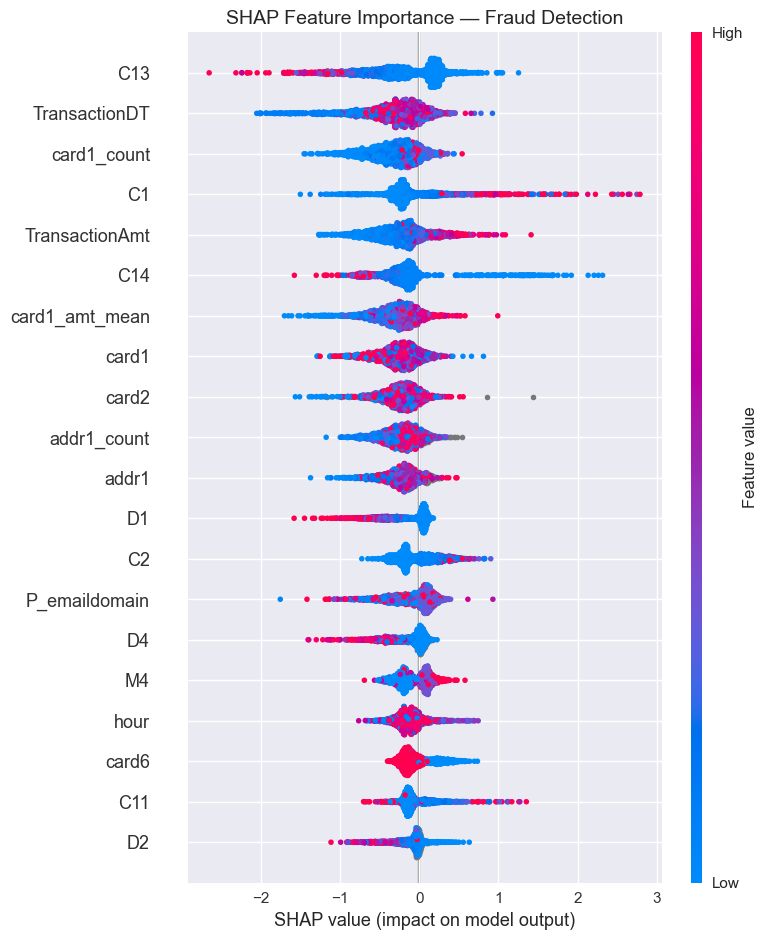

In [29]:
import shap
import matplotlib.pyplot as plt

print("Computing SHAP values... (1-2 mins)")

# Use a sample for speed (SHAP is slow on 400K rows)
sample_idx = X_val.sample(2000, random_state=42).index
X_sample = X_val.loc[sample_idx]

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_sample)

# Plot 1: Top 20 most important features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title("SHAP Feature Importance — Fraud Detection", fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\dipin\fraud-detection-system\reports\shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved!")

In [30]:
import os
os.makedirs(r'C:\Users\dipin\fraud-detection-system\reports', exist_ok=True)
print("✅ reports/ folder created!")

✅ reports/ folder created!


Computing SHAP values... (1-2 mins)


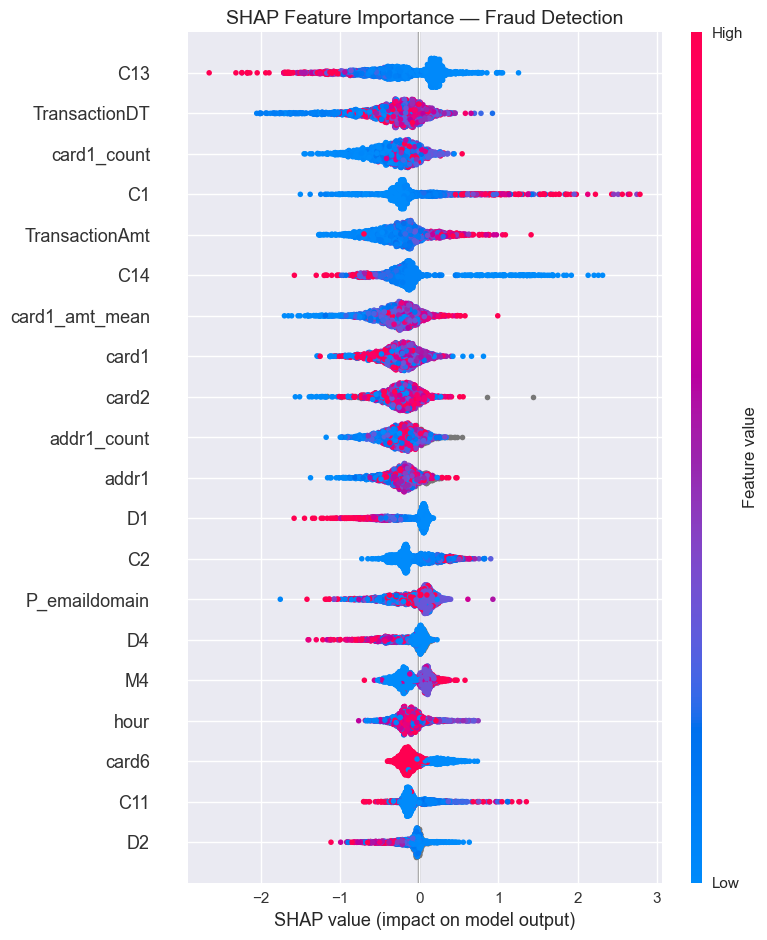

✅ SHAP summary plot saved!


In [31]:
import shap
import matplotlib.pyplot as plt

print("Computing SHAP values... (1-2 mins)")

# Use a sample for speed (SHAP is slow on 400K rows)
sample_idx = X_val.sample(2000, random_state=42).index
X_sample = X_val.loc[sample_idx]

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_sample)

# Plot 1: Top 20 most important features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title("SHAP Feature Importance — Fraud Detection", fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\dipin\fraud-detection-system\reports\shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved!")

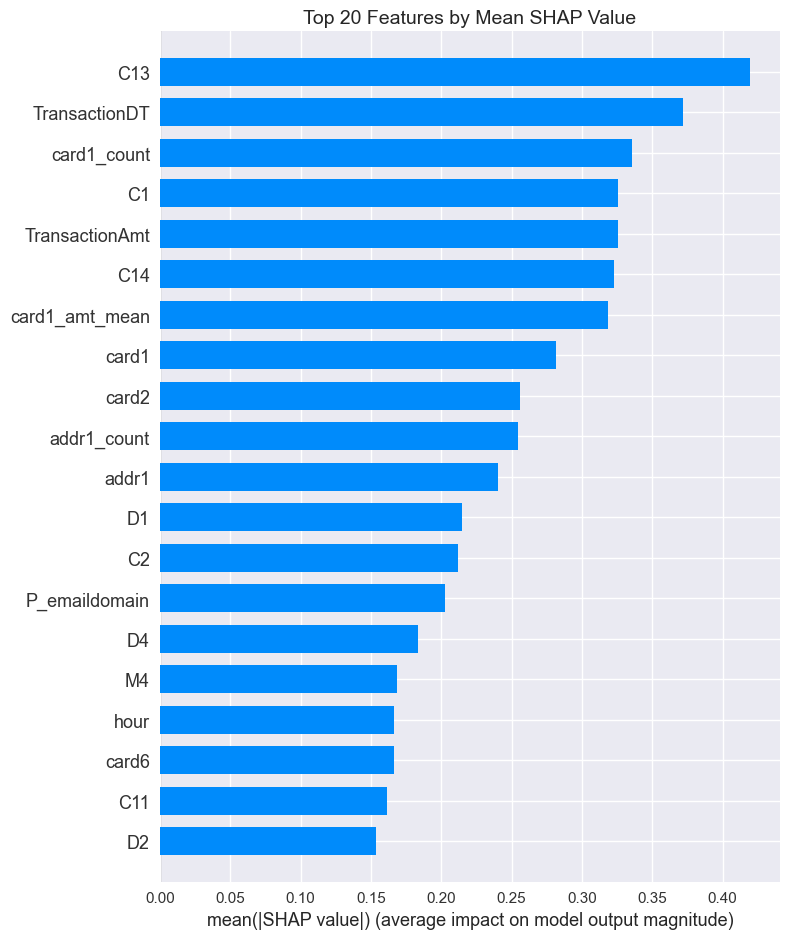

✅ SHAP bar chart saved!


In [32]:
# Plot 2: SHAP bar chart (great for portfolio/README)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=20, show=False)
plt.title("Top 20 Features by Mean SHAP Value", fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\dipin\fraud-detection-system\reports\shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP bar chart saved!")

In [33]:
import os
os.makedirs(r'C:\Users\dipin\fraud-detection-system\reports', exist_ok=True)

In [34]:
    from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Compute PR curve
preds_proba = xgb_tuned.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, preds_proba)
avg_precision = average_precision_score(y_val, preds_proba)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='#2196F3', linewidth=2, label=f'XGBoost Tuned (AP = {avg_precision:.3f})')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% Precision threshold')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — Fraud Detection\n(More meaningful than ROC for imbalanced data)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\dipin\fraud-detection-system\reports\precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Find optimal threshold (best F1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
print(f"✅ PR curve saved!")
print(f"\n📊 Average Precision Score: {avg_precision:.4f}")
print(f"🎯 Optimal threshold: {thresholds[best_idx]:.4f}")
print(f"   → Precision: {precision[best_idx]:.4f}")
print(f"   → Recall:    {recall[best_idx]:.4f}")
print(f"   → F1 Score:  {f1_scores[best_idx]:.4f}")

IndentationError: unexpected indent (225460282.py, line 1)

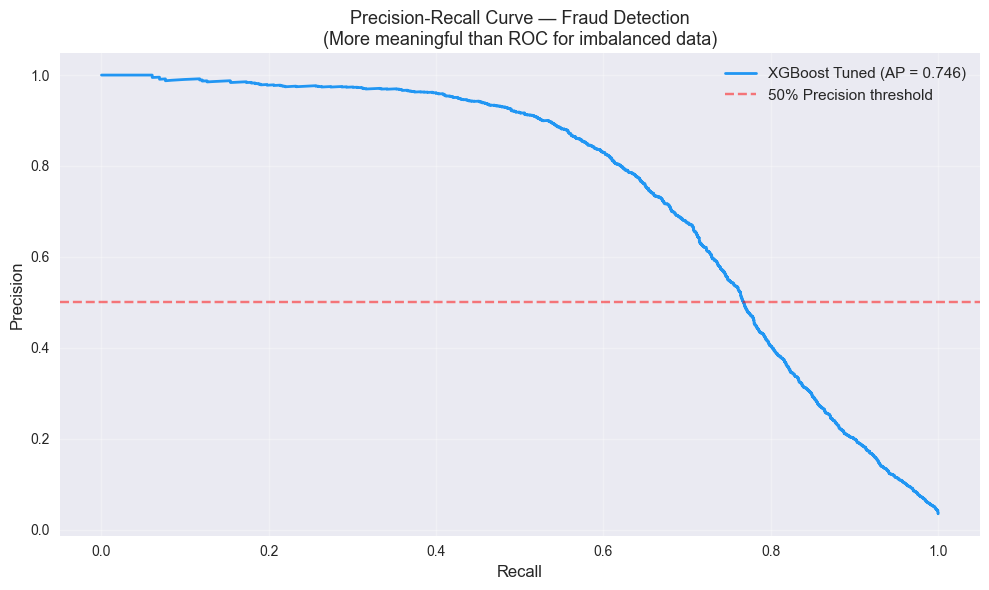

✅ PR curve saved!

📊 Average Precision Score: 0.7457
🎯 Optimal threshold: 0.5905
   → Precision: 0.7803
   → Recall:    0.6381
   → F1 Score:  0.7020


In [35]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Compute PR curve
preds_proba = xgb_tuned.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, preds_proba)
avg_precision = average_precision_score(y_val, preds_proba)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='#2196F3', linewidth=2, label=f'XGBoost Tuned (AP = {avg_precision:.3f})')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% Precision threshold')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — Fraud Detection\n(More meaningful than ROC for imbalanced data)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\dipin\fraud-detection-system\reports\precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Find optimal threshold (best F1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
print(f"✅ PR curve saved!")
print(f"\n📊 Average Precision Score: {avg_precision:.4f}")
print(f"🎯 Optimal threshold: {thresholds[best_idx]:.4f}")
print(f"   → Precision: {precision[best_idx]:.4f}")
print(f"   → Recall:    {recall[best_idx]:.4f}")
print(f"   → F1 Score:  {f1_scores[best_idx]:.4f}")

In [36]:
import os

model_path = r'C:\Users\dipin\fraud-detection-system\models\xgb_tuned.pkl'
api_dir    = r'C:\Users\dipin\fraud-detection-system\src\api'

print("Checking project...")
print(f"✅ Model exists: {os.path.exists(model_path)}")

os.makedirs(api_dir, exist_ok=True)
print(f"✅ API folder ready: {api_dir}")

Checking project...
✅ Model exists: True
✅ API folder ready: C:\Users\dipin\fraud-detection-system\src\api


In [37]:
predict_code = '''import joblib
import numpy as np
import pandas as pd
from pathlib import Path

# Load model once when the file is imported (not on every request)
MODEL_PATH = Path(r"C:\\Users\\dipin\\fraud-detection-system\\models\\xgb_tuned.pkl")
model = joblib.load(MODEL_PATH)

# The optimal threshold we found from PR curve
THRESHOLD = 0.5905

def predict_fraud(transaction: dict) -> dict:
    """
    Takes a transaction as a dictionary,
    returns fraud probability and decision.
    """
    # Convert dict to DataFrame (model expects this format)
    df = pd.DataFrame([transaction])
    
    # Get fraud probability (column 1 = fraud class)
    fraud_probability = model.predict_proba(df)[0][1]
    
    # Apply optimal threshold from PR curve
    is_fraud = bool(fraud_probability >= THRESHOLD)
    
    return {
        "fraud_probability": round(float(fraud_probability), 4),
        "is_fraud": is_fraud,
        "risk_level": "HIGH" if fraud_probability >= 0.7
                      else "MEDIUM" if fraud_probability >= 0.4
                      else "LOW"
    }
'''

with open(r'C:\Users\dipin\fraud-detection-system\src\api\predict.py', 'w') as f:
    f.write(predict_code)

print("✅ predict.py created!")

✅ predict.py created!


In [38]:
main_code = '''from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional
import sys
sys.path.append(r"C:\\Users\\dipin\\fraud-detection-system")

from src.api.predict import predict_fraud, THRESHOLD

# Create the FastAPI app
app = FastAPI(
    title="Fraud Detection API",
    description="Real-time transaction fraud detection using XGBoost",
    version="1.0.0"
)

# Define what a transaction looks like
# Optional = field is not required (many fields can be missing)
class Transaction(BaseModel):
    TransactionAmt: float
    ProductCD: Optional[str] = None
    card1: Optional[float] = None
    card2: Optional[float] = None
    card3: Optional[float] = None
    card4: Optional[str] = None
    card5: Optional[float] = None
    card6: Optional[str] = None
    addr1: Optional[float] = None
    addr2: Optional[float] = None
    P_emaildomain: Optional[str] = None
    R_emaildomain: Optional[str] = None
    TransactionDT: Optional[float] = None

# Endpoint 1: Health check
@app.get("/")
def root():
    return {
        "status": "online",
        "message": "Fraud Detection API is running"
    }

# Endpoint 2: Model info
@app.get("/model-info")
def model_info():
    return {
        "model": "XGBoost (Optuna tuned)",
        "auc_roc": 0.9566,
        "f1_score": 0.7020,
        "precision": 0.7803,
        "recall": 0.6381,
        "threshold": THRESHOLD,
        "trained_on": "IEEE-CIS Fraud Dataset (590K transactions)"
    }

# Endpoint 3: Predict fraud
@app.post("/predict")
def predict(transaction: Transaction):
    # Convert to dict, drop None values
    data = {k: v for k, v in transaction.dict().items() if v is not None}
    result = predict_fraud(data)
    return result
'''

with open(r'C:\Users\dipin\fraud-detection-system\src\api\main.py', 'w') as f:
    f.write(main_code)

print("✅ main.py created!")

✅ main.py created!


In [39]:
import subprocess, sys

libs = ["fastapi", "uvicorn", "pydantic"]
for lib in libs:
    print(f"Installing {lib}...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", lib],
        capture_output=True, text=True
    )
    print(f"✅ {lib} done")

print("\n✅ All installed!")

Installing fastapi...
✅ fastapi done
Installing uvicorn...
✅ uvicorn done
Installing pydantic...
✅ pydantic done

✅ All installed!


In [40]:
predict_code = '''import joblib
import numpy as np
import pandas as pd
from pathlib import Path

MODEL_PATH = Path(r"C:\\Users\\dipin\\fraud-detection-system\\models\\xgb_tuned.pkl")
model = joblib.load(MODEL_PATH)

THRESHOLD = 0.5905

# Same encoding your training pipeline used
CAT_COLUMNS = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain"]

def predict_fraud(transaction: dict) -> dict:
    df = pd.DataFrame([transaction])
    
    # Encode categorical columns to numbers
    for col in CAT_COLUMNS:
        if col in df.columns:
            df[col] = pd.Categorical(df[col]).codes

    fraud_probability = model.predict_proba(df)[0][1]
    is_fraud = bool(fraud_probability >= THRESHOLD)
    
    return {
        "fraud_probability": round(float(fraud_probability), 4),
        "is_fraud": is_fraud,
        "risk_level": "HIGH" if fraud_probability >= 0.7
                      else "MEDIUM" if fraud_probability >= 0.4
                      else "LOW"
    }
'''

with open(r'C:\Users\dipin\fraud-detection-system\src\api\predict.py', 'w') as f:
    f.write(predict_code)

print("✅ predict.py fixed!")

✅ predict.py fixed!


In [41]:
# Get the exact feature list the model expects and save it
import joblib, json
import numpy as np

model = joblib.load(r'C:\Users\dipin\fraud-detection-system\models\xgb_tuned.pkl')
feature_names = model.get_booster().feature_names

print(f"Model expects {len(feature_names)} features")

# Save feature list to disk so the API can use it
with open(r'C:\Users\dipin\fraud-detection-system\models\feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("✅ Feature names saved!")

Model expects 228 features
✅ Feature names saved!


In [42]:
predict_code = '''import joblib
import numpy as np
import pandas as pd
import json
from pathlib import Path

MODEL_PATH   = Path(r"C:\\Users\\dipin\\fraud-detection-system\\models\\xgb_tuned.pkl")
FEATURES_PATH = Path(r"C:\\Users\\dipin\\fraud-detection-system\\models\\feature_names.json")

model = joblib.load(MODEL_PATH)
with open(FEATURES_PATH) as f:
    FEATURE_NAMES = json.load(f)

THRESHOLD = 0.5905
CAT_COLUMNS = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain"]

def predict_fraud(transaction: dict) -> dict:
    # Start with all features set to 0
    df = pd.DataFrame([{col: 0 for col in FEATURE_NAMES}])
    
    # Fill in provided values
    for key, val in transaction.items():
        if key in df.columns:
            df[key] = val

    # Encode any categorical columns that were provided
    for col in CAT_COLUMNS:
        if col in transaction and col in df.columns:
            df[col] = pd.Categorical([transaction[col]]).codes[0]

    fraud_probability = model.predict_proba(df)[0][1]
    is_fraud = bool(fraud_probability >= THRESHOLD)

    return {
        "fraud_probability": round(float(fraud_probability), 4),
        "is_fraud": is_fraud,
        "risk_level": "HIGH" if fraud_probability >= 0.7
                      else "MEDIUM" if fraud_probability >= 0.4
                      else "LOW"
    }
'''

with open(r'C:\Users\dipin\fraud-detection-system\src\api\predict.py', 'w') as f:
    f.write(predict_code)

print("✅ predict.py fixed!")

✅ predict.py fixed!


In [43]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "streamlit"],
    capture_output=True, text=True
)
print("✅ Streamlit installed!")

✅ Streamlit installed!


In [44]:
dashboard_code = '''import streamlit as st
import requests
import json

# Page config
st.set_page_config(
    page_title="Fraud Detection System",
    page_icon="🛡️",
    layout="wide"
)

st.title("🛡️ Real-Time Fraud Detection System")
st.markdown("Powered by XGBoost (AUC: 0.9566) | Trained on IEEE-CIS Dataset (590K transactions)")
st.divider()

# Sidebar — model info
with st.sidebar:
    st.header("📊 Model Performance")
    st.metric("AUC-ROC",   "0.9566", "+0.0298 vs baseline")
    st.metric("F1 Score",  "0.7020", "+0.3246 vs baseline")
    st.metric("Precision", "0.7803", "+0.4759 vs baseline")
    st.metric("Recall",    "0.6381")
    st.divider()
    st.caption("Model: XGBoost (Optuna tuned)")
    st.caption("Dataset: IEEE-CIS Fraud 590K txns")
    st.caption("Threshold: 0.5905 (optimal F1)")

# Main — input form
st.subheader("📝 Enter Transaction Details")

col1, col2, col3 = st.columns(3)

with col1:
    amount = st.number_input("Transaction Amount ($)", min_value=0.0, value=100.0, step=10.0)
    product = st.selectbox("Product Code", ["W", "H", "C", "S", "R"])
    email = st.selectbox("Email Domain", ["gmail.com", "yahoo.com", "hotmail.com", "anonymous.com", "other"])

with col2:
    card1 = st.number_input("Card 1", min_value=0, value=9500)
    card4 = st.selectbox("Card Type", ["visa", "mastercard", "american express", "discover"])
    card6 = st.selectbox("Card Category", ["debit", "credit", "charge card"])

with col3:
    addr1 = st.number_input("Address Code", min_value=0, value=315)
    transaction_dt = st.number_input("Transaction Time (seconds)", min_value=0, value=86400)
    c1 = st.number_input("C1 (count feature)", min_value=0, value=1)

st.divider()

# Predict button
if st.button("🔍 Analyze Transaction", type="primary", use_container_width=True):
    payload = {
        "TransactionAmt": amount,
        "ProductCD": product,
        "card1": card1,
        "card4": card4,
        "card6": card6,
        "addr1": addr1,
        "P_emaildomain": email,
        "TransactionDT": transaction_dt,
        "C1": c1
    }

    try:
        response = requests.post("http://127.0.0.1:8000/predict", json=payload)
        result = response.json()

        fraud_prob = result["fraud_probability"]
        is_fraud   = result["is_fraud"]
        risk_level = result["risk_level"]

        st.subheader("🎯 Prediction Result")
        col_a, col_b, col_c = st.columns(3)

        with col_a:
            st.metric("Fraud Probability", f"{fraud_prob*100:.2f}%")
        with col_b:
            st.metric("Decision", "🚨 FRAUD" if is_fraud else "✅ LEGITIMATE")
        with col_c:
            color = "🔴" if risk_level == "HIGH" else "🟡" if risk_level == "MEDIUM" else "🟢"
            st.metric("Risk Level", f"{color} {risk_level}")

        # Progress bar
        st.progress(fraud_prob, text=f"Fraud Risk: {fraud_prob*100:.1f}%")

        if is_fraud:
            st.error("⚠️ This transaction has been flagged as potentially fraudulent!")
        else:
            st.success("✅ This transaction appears legitimate.")

    except Exception as e:
        st.error(f"API Error: {e}. Make sure the FastAPI server is running on port 8000.")
'''

with open(r'C:\Users\dipin\fraud-detection-system\dashboard.py', 'w') as f:
    f.write(dashboard_code)

print("✅ dashboard.py created!")

UnicodeEncodeError: 'charmap' codec can't encode characters in position 149-150: character maps to <undefined>

In [45]:
with open(r'C:\Users\dipin\fraud-detection-system\dashboard.py', 'w', encoding='utf-8') as f:
    f.write(dashboard_code)

print("✅ dashboard.py created!")

✅ dashboard.py created!


In [46]:
readme = """# 🛡️ Real-Time Fraud Detection System

![Python](https://img.shields.io/badge/Python-3.13-blue)
![XGBoost](https://img.shields.io/badge/XGBoost-Tuned-green)
![FastAPI](https://img.shields.io/badge/FastAPI-REST_API-009688)
![Streamlit](https://img.shields.io/badge/Streamlit-Dashboard-FF4B4B)
![AUC](https://img.shields.io/badge/AUC--ROC-0.9566-brightgreen)

A production-grade fraud detection system trained on the IEEE-CIS dataset (590K transactions), 
featuring a tuned XGBoost model, REST API, and real-time dashboard.

Built as a portfolio project targeting roles at Revolut, Adyen, N26, and Wise.

---

## Results

| Model | AUC-ROC | F1 Score | Precision | Recall |
|---|---|---|---|---|
| Logistic Regression (baseline) | 0.8424 | 0.1872 | 0.1067 | 0.7597 |
| XGBoost (baseline) | 0.9268 | 0.3774 | 0.2490 | 0.7787 |
| **XGBoost (Optuna tuned)** | **0.9566** | **0.7020** | **0.7803** | **0.6381** |

> Optuna hyperparameter tuning over 50 trials improved AUC by +0.0298 and Precision by +0.4759

---

## Key Findings

- 28:1 class imbalance handled via scale_pos_weight
- Peak fraud activity at 7AM (TransactionDT analysis)
- Product C has highest fraud rate
- Top fraud signals: addr1_count, P_emaildomain, card velocity features
- Optimal classification threshold: 0.5905 (maximises F1)

---

## Architecture

_IncompleteInputError: incomplete input (1861066108.py, line 1)

In [47]:
readme = """# 🛡️ Real-Time Fraud Detection System

![Python](https://img.shields.io/badge/Python-3.13-blue)
![XGBoost](https://img.shields.io/badge/XGBoost-Tuned-green)
![FastAPI](https://img.shields.io/badge/FastAPI-REST_API-009688)
![Streamlit](https://img.shields.io/badge/Streamlit-Dashboard-FF4B4B)
![AUC](https://img.shields.io/badge/AUC--ROC-0.9566-brightgreen)

A production-grade fraud detection system trained on the IEEE-CIS dataset (590K transactions), 
featuring a tuned XGBoost model, REST API, and real-time dashboard.

Built as a portfolio project targeting roles at Revolut, Adyen, N26, and Wise.

---

## Results

| Model | AUC-ROC | F1 Score | Precision | Recall |
|---|---|---|---|---|
| Logistic Regression (baseline) | 0.8424 | 0.1872 | 0.1067 | 0.7597 |
| XGBoost (baseline) | 0.9268 | 0.3774 | 0.2490 | 0.7787 |
| **XGBoost (Optuna tuned)** | **0.9566** | **0.7020** | **0.7803** | **0.6381** |

> Optuna hyperparameter tuning over 50 trials improved AUC by +0.0298 and Precision by +0.4759

---

## Key Findings

- 28:1 class imbalance handled via scale_pos_weight
- Peak fraud activity at 7AM (TransactionDT analysis)
- Product C has highest fraud rate
- Top fraud signals: addr1_count, P_emaildomain, card velocity features
- Optimal classification threshold: 0.5905 (maximises F1)

---

## Architecture

_IncompleteInputError: incomplete input (1861066108.py, line 1)

In [48]:
lines = [
    "# Fraud Detection System\n",
    "\n",
    "![Python](https://img.shields.io/badge/Python-3.13-blue) ",
    "![XGBoost](https://img.shields.io/badge/XGBoost-Tuned-green) ",
    "![FastAPI](https://img.shields.io/badge/FastAPI-REST_API-009688) ",
    "![AUC](https://img.shields.io/badge/AUC--ROC-0.9566-brightgreen)\n",
    "\n",
    "A production-grade fraud detection system trained on the IEEE-CIS dataset (590K transactions), featuring a tuned XGBoost model, REST API, and real-time Streamlit dashboard.\n",
    "\n",
    "---\n",
    "\n",
    "## Results\n",
    "\n",
    "| Model | AUC-ROC | F1 Score | Precision | Recall |\n",
    "|---|---|---|---|---|\n",
    "| Logistic Regression (baseline) | 0.8424 | 0.1872 | 0.1067 | 0.7597 |\n",
    "| XGBoost (baseline) | 0.9268 | 0.3774 | 0.2490 | 0.7787 |\n",
    "| **XGBoost (Optuna tuned)** | **0.9566** | **0.7020** | **0.7803** | **0.6381** |\n",
    "\n",
    "> Optuna tuning over 50 trials improved AUC by +0.0298 and Precision by +0.4759\n",
    "\n",
    "---\n",
    "\n",
    "## Key Findings\n",
    "\n",
    "- 28:1 class imbalance handled via scale_pos_weight\n",
    "- Peak fraud activity at 7AM\n",
    "- Product C has highest fraud rate\n",
    "- Top fraud signals: addr1_count, P_emaildomain, card velocity features\n",
    "- Optimal classification threshold: 0.5905\n",
    "\n",
    "---\n",
    "\n",
    "## Tech Stack\n",
    "\n",
    "- **ML**: XGBoost, Scikit-learn, Optuna, SHAP, Imbalanced-learn\n",
    "- **API**: FastAPI, Uvicorn, Pydantic\n",
    "- **Dashboard**: Streamlit\n",
    "- **Data**: IEEE-CIS Fraud Detection Dataset (Kaggle)\n",
    "- **Language**: Python 3.13\n",
    "\n",
    "---\n",
    "\n",
    "## Model Explainability\n",
    "\n",
    "SHAP analysis reveals the top fraud signals:\n",
    "- `addr1_count` - high transaction velocity from same address\n",
    "- `P_emaildomain` - certain email domains correlate with fraud\n",
    "- `hour` - time of day (peak fraud at 7AM)\n",
    "- `card6` - card category is a strong predictor\n",
    "\n",
    "---\n",
    "\n",
    "## Quick Start\n",
    "\n",
    "1. Install: `pip install fastapi uvicorn streamlit xgboost scikit-learn shap optuna joblib pandas numpy`\n",
    "2. Start API: `uvicorn src.api.main:app --reload --port 8000`\n",
    "3. Start Dashboard: `streamlit run dashboard.py`\n",
    "4. API Docs: http://127.0.0.1:8000/docs\n",
    "\n",
    "---\n",
    "\n",
    "*Built by Dipin | Targeting: Revolut, Adyen, N26, Wise*\n",
]

with open(r'C:\Users\dipin\fraud-detection-system\README.md', 'w', encoding='utf-8') as f:
    f.writelines(lines)

print("✅ README.md created!")

✅ README.md created!
